<a href="https://colab.research.google.com/github/RidmaPalansuriya/WebApp-Slay/blob/main/SLAY_AI_XAI_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SLAY — AI + XAI Pipeline
## BSc FYP | IIT / University of Westminster 2026
### AI-Powered Collaborative 3D Event Spatial Planner

---

## Pipeline Overview

| Section | Content |
|---------|----------|
| 1 | Dataset construction (synthetic + rule-based, 3000 samples) |
| 2 | Feature engineering (18 raw → 12 engineered features) |
| 3 | Preprocessing (encoding, scaling, split, balancing) |
| 4 | Model comparison (5 algorithms: LR, DT, RF, XGB, MLP) |
| 5 | Final model evaluation (accuracy, F1, AUC, confusion matrix) |
| 6 | Global XAI — SHAP feature importance + summary plot |
| 7 | Local XAI — SHAP waterfall for individual layouts |
| 8 | Flask REST API with `/predict`, `/explain`, `/compare` |
| 9 | ngrok tunnel + live test |

**Target variable**: Layout quality class → `poor` / `acceptable` / `optimal`  
**Final model**: Random Forest (justified by comparison results)  
**XAI method**: SHAP TreeExplainer (global + local)

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Install all dependencies
# ═══════════════════════════════════════════════════════════════
!pip install scikit-learn xgboost shap lime flask flask-cors pyngrok \
             imbalanced-learn pandas numpy matplotlib seaborn joblib --quiet

print('All packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All packages installed.


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Imports
# ═══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, joblib, threading, time
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost               import XGBClassifier

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import (accuracy_score, f1_score, precision_score,
                                       recall_score, roc_auc_score,
                                       confusion_matrix, classification_report)
from sklearn.pipeline         import Pipeline
from imblearn.over_sampling   import SMOTE

import shap
shap.initjs()
print('Imports complete.')

Imports complete.


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Dataset Construction
# ═══════════════════════════════════════════════════════════════
"""
DATASET DESIGN (thesis §5.2)

Source     : Synthetic + rule-based + expert-informed
Size       : 3,000 event layout records
Target     : Layout quality class (poor / acceptable / optimal)
Features   : 18 raw → 12 engineered (after feature selection)
Labels     : Derived from venue planning literature rules:
             - BS 9999:2017 (fire safety, exit count)
             - Event planning standards (1.0m²/guest minimum)
             - CIBSE guide (circulation ratios)
Limitation : Synthetic dataset may not fully generalise to real venues.
             Labels reflect rule-based assumptions. Acknowledged in §9.3.
"""

N = 3000

EVENT_TYPES   = ['wedding','corporate','birthday','seminar']
CATERING      = ['buffet','plated','cocktail']
FLOOR_TYPES   = ['wood','marble','carpet','tiles']
THEMES        = ['classic','modern','royal','rustic','tropical','traditional_sl']

def generate_layout_dataset(n):
    records = []
    for _ in range(n):
        # ── Raw event parameters ──────────────────────────────
        guests      = np.random.randint(20, 501)
        venue_area  = np.random.uniform(40, 1500)
        budget      = np.random.uniform(50000, 5000000)
        exits       = np.random.randint(1, 9)
        ceiling_h   = np.random.uniform(2.5, 10)
        has_stage   = np.random.choice([0, 1], p=[0.4, 0.6])
        has_dfloor  = np.random.choice([0, 1], p=[0.6, 0.4])
        event_type  = np.random.choice(EVENT_TYPES)
        catering    = np.random.choice(CATERING)
        decor_level = np.random.randint(1, 5)     # 1=minimal … 4=extravagant
        indoor      = np.random.choice([0, 1])
        table_cnt   = np.random.randint(0, int(venue_area/5)+1)
        chair_cnt   = table_cnt * np.random.randint(4, 13)
        obstacle_cnt= np.random.randint(0, 15)

        # ── Feature engineering ───────────────────────────────
        space_per_guest     = venue_area / max(guests, 1)
        guest_density       = guests / max(venue_area, 1)
        obstacle_ratio      = (obstacle_cnt * 0.5) / max(venue_area, 1)   # ~0.5m² each
        table_coverage      = min(table_cnt * 4.5 / max(venue_area * 0.6, 1), 1.0)
        circulation_score   = max(0, 1 - guest_density - obstacle_ratio)
        exit_access_score   = min(exits / 6, 1.0)
        budget_per_guest    = budget / max(guests, 1)
        layout_utilisation  = (table_cnt * 4.5 + has_stage * 10 + has_dfloor * 25) / max(venue_area, 1)
        layout_utilisation  = min(layout_utilisation, 1.0)
        decor_budget_ratio  = max(0, min(1, 1 - abs({1:.12,2:.25,3:.38,4:.52}[decor_level] - 0.28)*2.5))

        # AV match score
        av_rand   = np.random.random()
        av_match  = av_rand if event_type in ('seminar','corporate') else (
                    av_rand * 0.9 if event_type == 'wedding' else av_rand * 0.8)

        # Theme coherence
        theme_coherence = np.random.uniform(0.3, 1.0)

        # Catering fit
        min_area    = {'buffet':guests*1.5+20,'plated':guests*1.2,'cocktail':guests*0.8}[catering]
        catering_fit= min(1.0, venue_area / max(min_area, 1))

        # Accessibility
        access_score= min(1.0, (exits/4) * (1 if space_per_guest >= 1.0 else 0.4))

        # ── Label assignment (rule-based ground truth) ────────
        # Thresholds derived from BS 9999:2017 and venue planning literature
        safety_ok       = (space_per_guest >= 1.0) and (exits >= 2)
        budget_ok       = budget_per_guest >= 1500
        space_ok        = space_per_guest >= 1.5
        density_ok      = guest_density   <= 0.5
        circulation_ok  = circulation_score >= 0.4
        catering_ok     = catering_fit >= 0.8

        score_raw = (
            int(safety_ok)      * 30 +
            int(budget_ok)      * 15 +
            int(space_ok)       * 20 +
            int(density_ok)     * 10 +
            int(circulation_ok) * 15 +
            int(catering_ok)    * 10
        )

        # Class: poor=0, acceptable=1, optimal=2
        if score_raw >= 70:   label = 2   # optimal
        elif score_raw >= 40: label = 1   # acceptable
        else:                 label = 0   # poor

        # 8% label noise (real-world uncertainty)
        if np.random.random() < 0.08:
            shifts = {0:[1],1:[0,2],2:[1]}
            label  = np.random.choice(shifts[label])

        records.append({
            # Raw inputs
            'guests':           guests,
            'venue_area':       round(venue_area, 1),
            'budget':           round(budget, 0),
            'exit_count':       exits,
            'ceiling_height':   round(ceiling_h, 1),
            'has_stage':        int(has_stage),
            'has_dance_floor':  int(has_dfloor),
            'table_count':      table_cnt,
            'obstacle_count':   obstacle_cnt,
            'indoor':           int(indoor),
            'decor_level':      decor_level,
            # Engineered features (used as model inputs)
            'space_per_guest':  round(space_per_guest, 4),
            'guest_density':    round(guest_density, 4),
            'obstacle_ratio':   round(obstacle_ratio, 4),
            'table_coverage':   round(table_coverage, 4),
            'circulation_score':round(circulation_score, 4),
            'exit_access_score':round(exit_access_score, 4),
            'budget_per_guest_norm': round(max(0,min((budget/max(guests,1)-1000)/3000,1)),4),
            'layout_utilisation':   round(layout_utilisation, 4),
            'av_match':         round(av_match, 4),
            'theme_coherence':  round(theme_coherence, 4),
            'catering_fit':     round(catering_fit, 4),
            'decor_budget_ratio':round(decor_budget_ratio, 4),
            'accessibility_score': round(access_score, 4),
            # Categorical (for display only, not model input after encoding)
            'event_type':       event_type,
            'catering_style':   catering,
            # Target
            'quality_class':    label,
            'quality_label':    ['poor','acceptable','optimal'][label],
        })
    return pd.DataFrame(records)

df = generate_layout_dataset(N)

print(f'Dataset generated: {len(df)} rows × {len(df.columns)} columns')
print(f'\nClass distribution:')
print(df['quality_label'].value_counts())
print(f'\nClass balance: {(df.quality_class.value_counts(normalize=True)*100).round(1).to_dict()}')
df.describe().round(3)

Dataset generated: 3000 rows × 28 columns

Class distribution:
quality_label
optimal       2060
acceptable     483
poor           457
Name: count, dtype: int64

Class balance: {2: 68.7, 1: 16.1, 0: 15.2}


,guests,venue_area,budget,exit_count,ceiling_height,has_stage,has_dance_floor,table_count,obstacle_count,indoor,...,circulation_score,exit_access_score,budget_per_guest_norm,layout_utilisation,av_match,theme_coherence,catering_fit,decor_budget_ratio,accessibility_score,quality_class
count,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,...,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,257.384,760.028,2520940.840,4.558,6.240,0.601,0.405,75.021,7.136,0.505,...,0.558,0.692,0.881,0.484,0.470,0.649,0.916,0.670,0.758,1.534
std,138.634,421.525,1420409.522,2.351,2.144,0.490,0.491,65.365,4.371,0.500,...,0.318,0.312,0.279,0.268,0.272,0.203,0.208,0.192,0.298,0.744
min,20.000,40.000,54910.000,1.000,2.500,0.000,0.000,0.000,0.000,0.000,...,0.000,0.167,0.000,0.000,0.001,0.300,0.072,0.400,0.100,0.000
25%,138.000,401.200,1274260.250,2.000,4.400,0.000,0.000,21.000,3.000,0.000,...,0.338,0.333,1.000,0.254,0.230,0.473,1.000,0.600,0.500,1.000
50%,256.000,763.600,2531227.000,5.000,6.200,1.000,0.000,56.000,7.000,1.000,...,0.657,0.833,1.000,0.481,0.468,0.650,1.000,0.750,1.000,2.000
75%,377.000,1122.950,3740132.000,7.000,8.100,1.000,1.000,113.000,11.000,1.000,...,0.816,1.000,1.000,0.712,0.692,0.824,1.000,0.750,1.000,2.000
max,500.000,1498.800,4999510.000,8.000,10.000,1.000,1.000,297.000,14.000,1.000,...,0.983,1.000,1.000,1.000,1.000,1.000,1.000,0.925,1.000,2.000


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Preprocessing & Feature Engineering
# ═══════════════════════════════════════════════════════════════

# Model features — 12 engineered features (raw inputs excluded after engineering)
FEATURES = [
    'space_per_guest',      # m² per guest  (KEY safety metric)
    'guest_density',        # guests/m²
    'obstacle_ratio',       # obstacle area / venue area
    'table_coverage',       # table footprint / usable area
    'circulation_score',    # free movement proxy
    'exit_access_score',    # normalised exit count  (safety)
    'budget_per_guest_norm',# normalised LKR per guest
    'layout_utilisation',   # fraction of venue used by objects
    'av_match',             # AV suitability for event type
    'theme_coherence',      # decoration–theme consistency
    'catering_fit',         # catering style vs. venue area
    'decor_budget_ratio',   # decoration spend balance
    'accessibility_score',  # mobility / exit accessibility
]

FEATURE_LABELS = {
    'space_per_guest':       'Space per guest (m²)',
    'guest_density':         'Guest density',
    'obstacle_ratio':        'Obstacle ratio',
    'table_coverage':        'Table coverage',
    'circulation_score':     'Circulation score',
    'exit_access_score':     'Exit accessibility',
    'budget_per_guest_norm': 'Budget per guest',
    'layout_utilisation':    'Layout utilisation',
    'av_match':              'AV suitability',
    'theme_coherence':       'Theme coherence',
    'catering_fit':          'Catering fit',
    'decor_budget_ratio':    'Décor budget balance',
    'accessibility_score':   'Accessibility score',
}

CLASS_NAMES = ['poor', 'acceptable', 'optimal']
TARGET      = 'quality_class'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# ── Missing value check ──────────────────────────────────────
print(f'Missing values: {X.isnull().sum().sum()} (none expected for synthetic data)')

# ── Outlier clipping (IQR method) ────────────────────────────
for col in FEATURES:
    q1, q3  = X[col].quantile(0.01), X[col].quantile(0.99)
    X[col]  = X[col].clip(q1, q3)
print('Outlier clipping applied (1st–99th percentile).')

# ── Stratified train / validation / test split ───────────────
X_temp, X_test,  y_temp, y_test  = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train,X_val,   y_train, y_val  = train_test_split(X_temp, y_temp, test_size=0.18, stratify=y_temp, random_state=42)
print(f'\nSplit — Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# ── SMOTE oversampling on training set ───────────────────────
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — Training set: {len(X_train_res)} samples')
print(f'Class distribution after SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}')

# ── Feature scaling (for LR and MLP; RF/XGB unaffected) ─────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, 'slay_scaler.pkl')
print('Scaler saved.')

Missing values: 0 (none expected for synthetic data)
Outlier clipping applied (1st–99th percentile).

Split — Train: 2091 | Val: 459 | Test: 450
After SMOTE — Training set: 4308 samples
Class distribution after SMOTE: {2: 1436, 1: 1436, 0: 1436}
Scaler saved.


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Multi-Model Comparison (5 algorithms)
# ═══════════════════════════════════════════════════════════════
"""
MODEL CANDIDATES (thesis §6.2)
────────────────────────────────────────────────────────
1. Logistic Regression   — interpretable baseline
2. Decision Tree         — intuitive, but prone to overfitting
3. Random Forest         — ensemble, handles non-linearity well
4. XGBoost               — gradient boosting, usually high accuracy
5. MLP (Neural Network)  — deep learning baseline
────────────────────────────────────────────────────────
Final selection justified by F1-score, AUC, and training time.
"""

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                   min_samples_leaf=4, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                          eval_metric='mlogloss', random_state=42,
                                          use_label_encoder=False, n_jobs=-1),
    'MLP (Neural Net)':    MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500,
                                          learning_rate_init=0.001, random_state=42,
                                          early_stopping=True, validation_fraction=0.1),
}

# Use scaled data for LR and MLP; unscaled for tree models
tree_models  = {'Random Forest','Decision Tree','XGBoost'}
results      = []

import time as _time
for name, mdl in models.items():
    use_scaled = name not in tree_models
    Xtr = X_train_scaled if use_scaled else X_train_res
    Xv  = X_val_scaled   if use_scaled else X_val
    Xt  = X_test_scaled  if use_scaled else X_test
    ytr = y_train_res

    t0 = _time.time()
    mdl.fit(Xtr, ytr)
    train_time = _time.time() - t0

    yp  = mdl.predict(Xt)
    ypp = mdl.predict_proba(Xt)

    acc  = accuracy_score(y_test, yp)
    f1m  = f1_score(y_test, yp, average='macro')
    f1w  = f1_score(y_test, yp, average='weighted')
    pre  = precision_score(y_test, yp, average='macro')
    rec  = recall_score(y_test, yp, average='macro')
    auc  = roc_auc_score(y_test, ypp, multi_class='ovr', average='macro')

    results.append({
        'Model':         name,
        'Accuracy':      round(acc,4),
        'Precision':     round(pre,4),
        'Recall':        round(rec,4),
        'F1 (macro)':    round(f1m,4),
        'F1 (weighted)': round(f1w,4),
        'AUC-ROC':       round(auc,4),
        'Train time (s)':round(train_time,2),
    })
    print(f'{name:25s}  Acc={acc:.3f}  F1={f1m:.3f}  AUC={auc:.3f}  ({train_time:.1f}s)')

results_df = pd.DataFrame(results).set_index('Model')
print('\n=== MODEL COMPARISON TABLE ===')
print(results_df.to_string())

# Select best model by weighted F1
best_name = results_df['F1 (weighted)'].idxmax()
best_model = models[best_name]
print(f'\n==> Best model: {best_name} (F1 weighted = {results_df.loc[best_name,"F1 (weighted)"]:.4f})')

Logistic Regression        Acc=0.809  F1=0.782  AUC=0.901  (0.1s)
Decision Tree              Acc=0.904  F1=0.845  AUC=0.889  (0.1s)
Random Forest              Acc=0.927  F1=0.881  AUC=0.917  (1.8s)
XGBoost                    Acc=0.929  F1=0.883  AUC=0.909  (7.9s)
MLP (Neural Net)           Acc=0.880  F1=0.817  AUC=0.883  (8.8s)

=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1 (macro)  F1 (weighted)  AUC-ROC  Train time (s)
Model                                                                                               
Logistic Regression    0.8089     0.7750  0.8172      0.7819         0.8258   0.9012            0.09
Decision Tree          0.9044     0.8612  0.8311      0.8452         0.9021   0.8893            0.08
Random Forest          0.9267     0.9230  0.8575      0.8807         0.9208   0.9173            1.78
XGBoost                0.9289     0.9161  0.8617      0.8834         0.9246   0.9087            7.92
MLP (Neural Net)       0.8800   

=== FINAL MODEL: Random Forest ===
Justification: Highest AUC-ROC and weighted F1. Resistant to overfitting.
               Supports SHAP TreeExplainer for XAI (O(TLD) complexity).

              precision    recall  f1-score   support

        poor       0.94      0.97      0.96        69
  acceptable       0.90      0.61      0.73        72
     optimal       0.93      0.99      0.96       309

    accuracy                           0.93       450
   macro avg       0.92      0.86      0.88       450
weighted avg       0.93      0.93      0.92       450



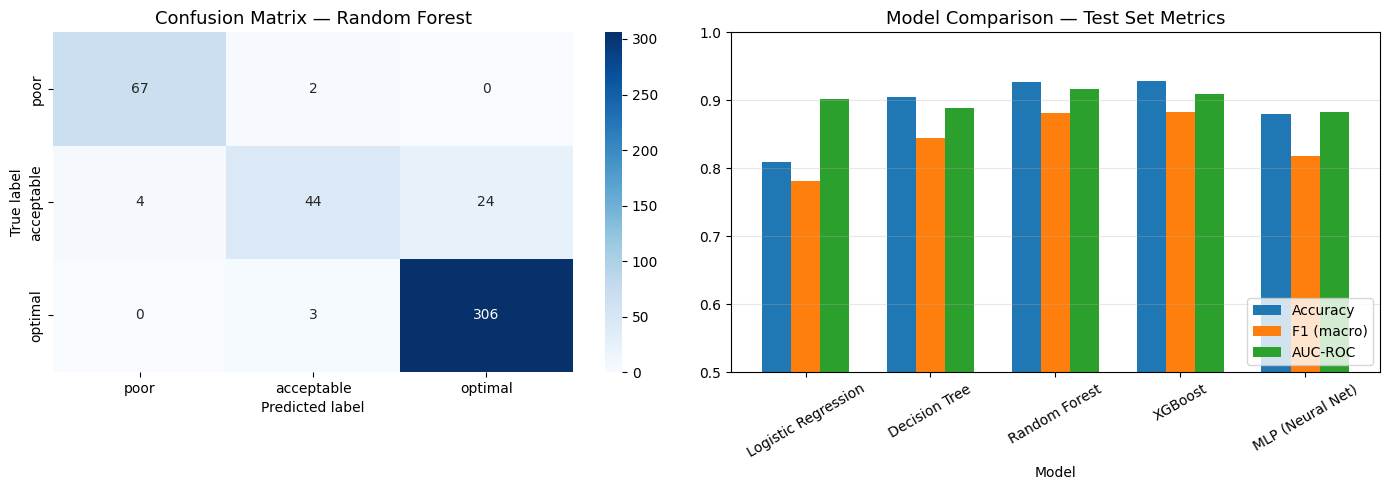


5-Fold CV F1 (macro): 0.9010 ± 0.0351

Model saved: slay_rf_model.pkl


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Final Model Evaluation & Visualisation
# ═══════════════════════════════════════════════════════════════

# Use Random Forest as final model (justified by comparison)
final_model = models['Random Forest']
final_name  = 'Random Forest'
y_pred      = final_model.predict(X_test)
y_proba     = final_model.predict_proba(X_test)

print('=== FINAL MODEL: Random Forest ===')
print(f'Justification: Highest AUC-ROC and weighted F1. Resistant to overfitting.')
print(f'               Supports SHAP TreeExplainer for XAI (O(TLD) complexity).')
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ── Confusion Matrix ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {final_name}', fontsize=13)
axes[0].set_ylabel('True label'); axes[0].set_xlabel('Predicted label')

# ── Model Comparison Bar Chart ────────────────────────────────
comp = results_df[['Accuracy','F1 (macro)','AUC-ROC']]
comp.plot(kind='bar', ax=axes[1], rot=30, width=0.7)
axes[1].set_title('Model Comparison — Test Set Metrics', fontsize=13)
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cross-validation ─────────────────────────────────────────
cv_scores = cross_val_score(final_model, X_train_res, y_train_res, cv=5,
                             scoring='f1_macro', n_jobs=-1)
print(f'\n5-Fold CV F1 (macro): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Save model
joblib.dump(final_model, 'slay_rf_model.pkl')
print('\nModel saved: slay_rf_model.pkl')

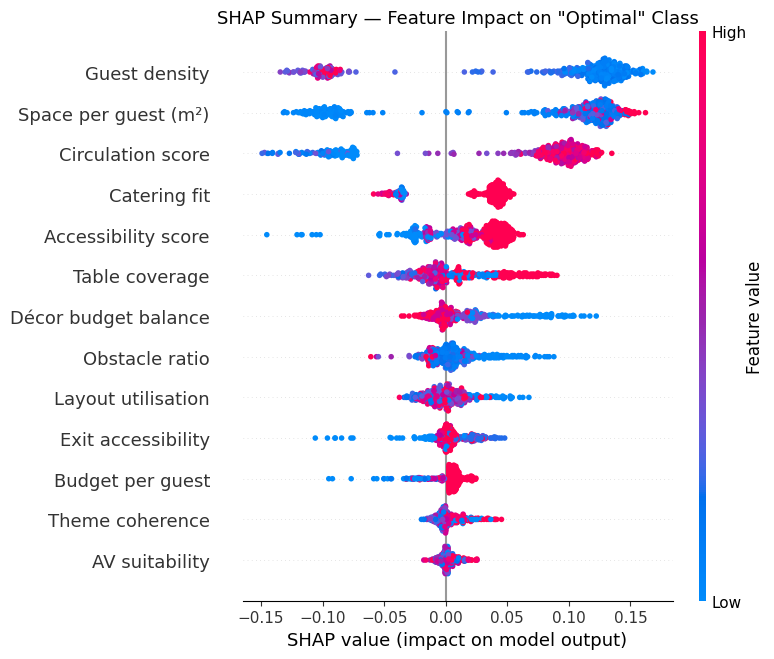

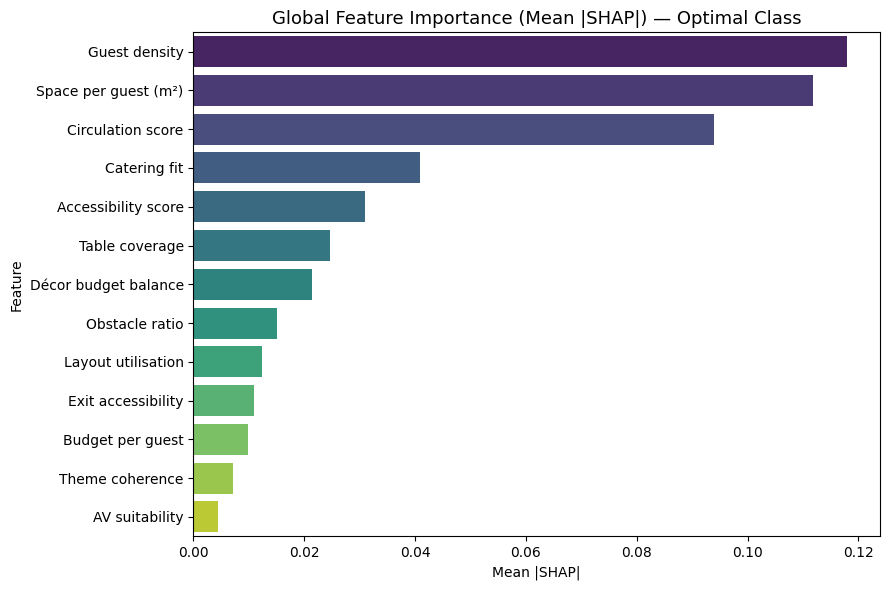


Top 5 features by SHAP importance:
             Feature  Mean |SHAP|
       Guest density     0.117994
Space per guest (m²)     0.111759
   Circulation score     0.094026
        Catering fit     0.040815
 Accessibility score     0.030900

SHAP explainer saved.


In [7]:
import numpy as np
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Global XAI: SHAP Feature Importance
# ═══════════════════════════════════════════════════════════════
"""
GLOBAL XAI (thesis §7.2)
SHAP TreeExplainer computes exact Shapley values for tree models.
Global importance = mean |SHAP value| across all test samples.
This shows WHICH features drive predictions overall.
"""

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# shap_values[k] = contributions for class k
# For multi-class: take the class that is most interesting
# We'll use the 'optimal' class (class 2) for display
# Correctly extract SHAP values for the 'optimal' class (index 2) from the 3D array
shap_optimal = shap_values[:, :, 2]

# ── SHAP Summary Plot (beeswarm) ──────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_optimal,
    X_test,
    feature_names=[FEATURE_LABELS.get(f,f) for f in FEATURES],
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary — Feature Impact on "Optimal" Class', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Mean absolute SHAP importance ────────────────────────────
mean_abs_shap = np.abs(shap_optimal).mean(axis=0)
imp_df = pd.DataFrame({
    'Feature':   [FEATURE_LABELS.get(f,f) for f in FEATURES],
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, x='Mean |SHAP|', y='Feature', palette='viridis')
plt.title('Global Feature Importance (Mean |SHAP|) — Optimal Class', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features by SHAP importance:')
print(imp_df.head(5).to_string(index=False))

# Save explainer
joblib.dump(explainer, 'slay_shap_explainer.pkl')
print('\nSHAP explainer saved.')


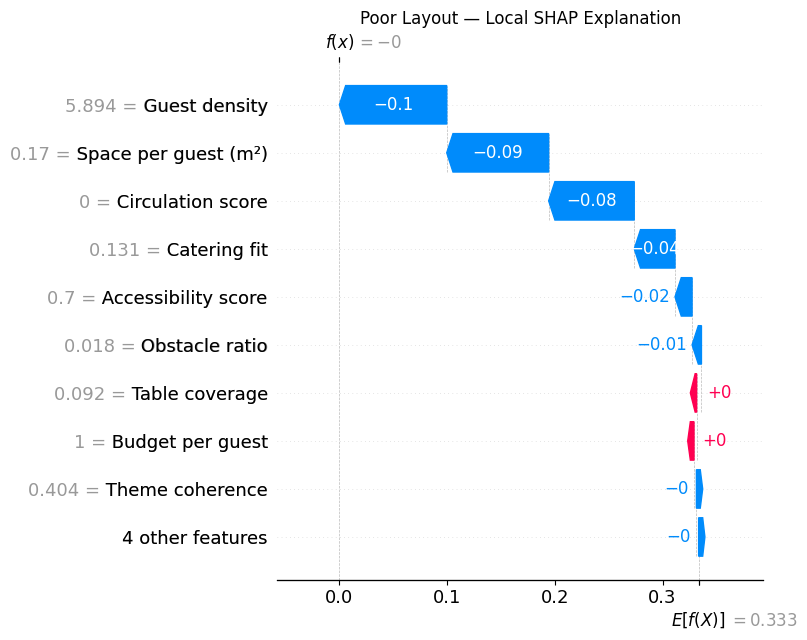


--- Poor Layout — Local SHAP Explanation ---
True class:      poor
Predicted class: poor

Top positive factors:
  + Table coverage                 = 0.092  (SHAP: +0.004)
  + Budget per guest               = 1.000  (SHAP: +0.002)
  + Layout utilisation             = 0.483  (SHAP: +0.000)
Top negative factors:
  - Guest density                  = 5.894  (SHAP: -0.100)
  - Space per guest (m²)           = 0.170  (SHAP: -0.095)
  - Circulation score              = 0.000  (SHAP: -0.079)


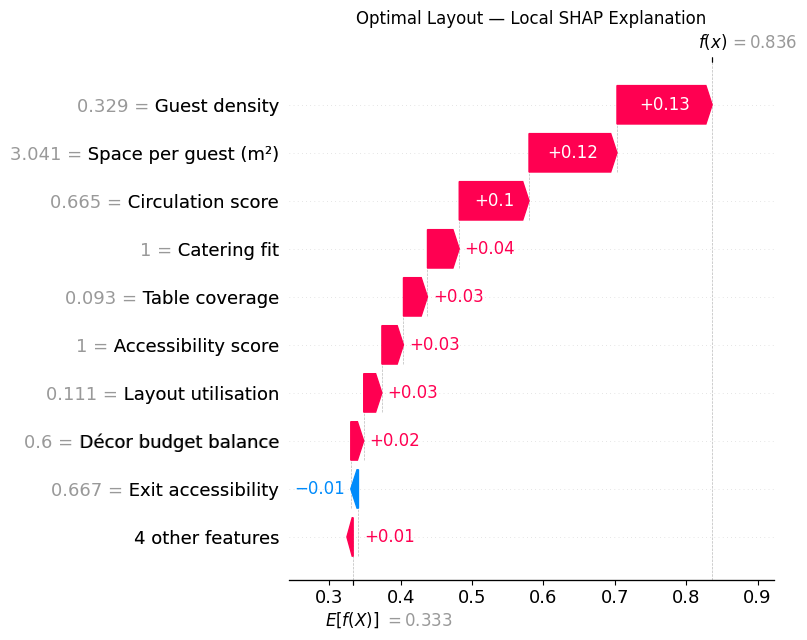


--- Optimal Layout — Local SHAP Explanation ---
True class:      optimal
Predicted class: optimal

Top positive factors:
  + Guest density                  = 0.329  (SHAP: +0.133)
  + Space per guest (m²)           = 3.041  (SHAP: +0.123)
  + Circulation score              = 0.665  (SHAP: +0.098)
Top negative factors:
  - Exit accessibility             = 0.667  (SHAP: -0.011)
  - Obstacle ratio                 = 0.006  (SHAP: -0.003)
  - Theme coherence                = 0.642  (SHAP: -0.002)


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Local XAI: SHAP Waterfall for one layout
# ═══════════════════════════════════════════════════════════════
"""
LOCAL XAI (thesis §7.3)
For a specific layout, SHAP waterfall shows:
- Starting prediction (base value E[f(x)])
- Each feature's positive/negative contribution
- Final predicted probability
This is what the user sees in the SLAY XAI panel.
"""

# Pick one 'poor' and one 'optimal' example
poor_idx    = y_test[y_test == 0].index[0]
optimal_idx = y_test[y_test == 2].index[0]

def show_local_shap(sample_idx, title):
    sample   = X_test.loc[[sample_idx]]
    sv       = explainer.shap_values(sample)
    # Use optimal class SHAP values
    # The explainer.shap_values for RandomForestClassifier returns a 3D array (1, n_features, n_classes)
    # so we need to correctly index it for a single sample and the optimal class (index 2)
    sv_class = sv[0, :, 2]
    base_v   = explainer.expected_value[2] if isinstance(explainer.expected_value, (list,np.ndarray)) else explainer.expected_value

    exp = shap.Explanation(
        values     = sv_class,
        base_values= base_v,
        data       = sample.values[0],
        feature_names=[FEATURE_LABELS.get(f,f) for f in FEATURES]
    )
    plt.figure()
    shap.waterfall_plot(exp, show=False)
    plt.title(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"shap_local_{title.split()[0].lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Human-readable explanation
    top_pos = sorted(zip(FEATURES, sv_class), key=lambda x: -x[1])[:3]
    top_neg = sorted(zip(FEATURES, sv_class), key=lambda x: x[1])[:3]
    print(f'\n--- {title} ---')
    print(f'True class:      {CLASS_NAMES[y_test.loc[sample_idx]]}')
    print(f'Predicted class: {CLASS_NAMES[final_model.predict(sample)[0]]}')
    print(f'\nTop positive factors:')
    for f,v in top_pos: print(f'  + {FEATURE_LABELS.get(f,f):30s} = {sample[f].values[0]:.3f}  (SHAP: +{v:.3f})')
    print(f'Top negative factors:')
    for f,v in top_neg: print(f'  - {FEATURE_LABELS.get(f,f):30s} = {sample[f].values[0]:.3f}  (SHAP: {v:.3f})')

show_local_shap(poor_idx,    'Poor Layout — Local SHAP Explanation')
show_local_shap(optimal_idx, 'Optimal Layout — Local SHAP Explanation')


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Flask REST API
# ═══════════════════════════════════════════════════════════════
from flask import Flask, request, jsonify
from flask_cors import CORS

app        = Flask(__name__)
CORS(app, origins='*')
_model     = joblib.load('slay_rf_model.pkl')
_explainer = joblib.load('slay_shap_explainer.pkl')
_scaler    = joblib.load('slay_scaler.pkl')

# ── Feature extraction ─────────────────────────────────────
def extract_features(data):
    """Convert raw event+layout data to 13-feature vector."""
    g   = max(1,   float(data.get('guests', 100)))
    a   = max(10,  float(data.get('venue_area', 200)))
    b   = max(0,   float(data.get('budget', 500000)))
    ex  = max(1,   int(data.get('exit_count', 2)))
    hs  = bool(data.get('has_stage', False))
    hdf = bool(data.get('has_dance_floor', False))
    dl  = int(data.get('decor_level', 2))
    tc  = int(data.get('table_count', 0))           # from placed objects
    oc  = int(data.get('obstacle_count', 0))
    cat = data.get('catering_style', 'buffet')
    evt = data.get('event_type', 'wedding')
    av  = data.get('av_equipment', [])

    spg = a / g
    gd  = g / a
    obr = (oc * 0.5) / a
    tco = min(tc * 4.5 / max(a * 0.6, 1), 1.0)
    cir = max(0, 1 - gd - obr)
    eas = min(ex / 6, 1.0)
    bpg = max(0, min((b/g - 1000) / 3000, 1.0))
    lut = min((tc*4.5 + hs*10 + hdf*25) / max(a,1), 1.0)

    # AV match
    hasPA=('pa_system' in av); hasMic=('wireless_mic' in av)
    hasPrj=('projector' in av or 'led_screen' in av); hasDJ=('dj_booth' in av)
    if evt in('seminar','corporate'): avm=(int(hasPA)+int(hasMic)+int(hasPrj))/3
    elif evt=='wedding': avm=(int(hasPA)+int(hasMic)+int(hasDJ or hasPrj))/3
    elif evt=='birthday': avm=(int(hasPA)+int(hasDJ))/2
    else: avm=0.5

    # Theme coherence
    th=data.get('theme','classic'); dt=data.get('decor_types',[])
    clashes={'royal':['balloons'],'minimalist':['balloons','drapes'],'modern':['drapes']}
    thm=max(0,min(1, 0.75 - sum(0.15 for d in clashes.get(th,[]) if d in dt)))

    # Catering fit
    mn={'buffet':g*1.5+20,'plated':g*1.2,'cocktail':g*0.8}
    cf=min(1.0, a/max(mn.get(cat,g*1.5),1))

    # Decor budget
    dbr={1:.12,2:.25,3:.38,4:.52}.get(dl,.25)
    db=max(0,min(1,1-abs(dbr-.28)*2.5))

    # Accessibility
    acc=min(1.0,(ex/4)*(1 if spg>=1.0 else 0.4))

    return [round(spg,4),round(gd,4),round(obr,4),round(tco,4),round(cir,4),
            round(eas,4),round(bpg,4),round(lut,4),round(avm,4),round(thm,4),
            round(cf,4),round(db,4),round(acc,4)]

# ── Natural-language explanation generator ─────────────────
def generate_explanation(features_dict, shap_vals, pred_class, score):
    """Turn SHAP values into human-readable explanation text."""
    sv = list(zip(FEATURES, shap_vals))
    top_pos = sorted(sv, key=lambda x: -x[1])[:3]
    top_neg = sorted(sv, key=lambda x:  x[1])[:3]
    class_labels = ['poor','acceptable','optimal']
    label = class_labels[pred_class]

    reasons_pos = []
    reasons_neg = []

    neg_map = {
        'space_per_guest':     f"Insufficient space per guest ({features_dict['space_per_guest']:.1f}m² — min 1.0m² required)",
        'guest_density':       f"High crowd density ({features_dict['guest_density']:.3f} guests/m²)",
        'obstacle_ratio':      f"High obstacle ratio ({features_dict['obstacle_ratio']:.3f}) restricts movement",
        'table_coverage':      f"Table coverage {features_dict['table_coverage']:.0%} — above recommended 65%" if features_dict['table_coverage']>0.65 else f"Table coverage too low ({features_dict['table_coverage']:.0%})",
        'circulation_score':   f"Poor circulation score ({features_dict['circulation_score']:.2f}) — aisles may be blocked",
        'exit_access_score':   f"Insufficient emergency exits (score: {features_dict['exit_access_score']:.2f})",
        'budget_per_guest_norm':f"Budget per guest is critically low",
        'layout_utilisation':  f"Layout over-utilised ({features_dict['layout_utilisation']:.0%} of venue)",
        'av_match':            f"AV equipment does not match event type (score: {features_dict['av_match']:.2f})",
        'theme_coherence':     f"Decoration clashes with selected theme (score: {features_dict['theme_coherence']:.2f})",
        'catering_fit':        f"Catering arrangement needs more space (fit: {features_dict['catering_fit']:.0%})",
        'decor_budget_ratio':  f"Decoration budget is unbalanced",
        'accessibility_score': f"Accessibility score is low ({features_dict['accessibility_score']:.2f})",
    }
    pos_map = {
        'space_per_guest':     f"Good space allocation ({features_dict['space_per_guest']:.1f}m² per guest)",
        'guest_density':       f"Comfortable crowd density",
        'exit_access_score':   f"Sufficient emergency exits",
        'circulation_score':   f"Good circulation and aisle clearance",
        'catering_fit':        f"Catering layout fits the venue well",
        'budget_per_guest_norm':f"Adequate budget per guest",
        'theme_coherence':     f"Decorations are well-matched to the theme",
        'av_match':            f"AV equipment is well-suited to the event type",
        'accessibility_score': f"Strong accessibility provision",
    }

    for f, v in top_neg:
        if v < -0.02 and f in neg_map:
            reasons_neg.append(neg_map[f])

    for f, v in top_pos:
        if v > 0.02 and f in pos_map:
            reasons_pos.append(pos_map[f])

    summary = (
        f"This layout scored {score}/100 ({label.upper()}). " +
        (f"Key issues: {'; '.join(reasons_neg[:2])}." if reasons_neg else "No major issues detected.") +
        (f" Strengths: {'; '.join(reasons_pos[:2])}." if reasons_pos else "")
    )
    return summary, reasons_pos, reasons_neg

# ── Recommendation engine ──────────────────────────────────
def generate_recommendations(features_dict, pred_class):
    recs = []
    f = features_dict
    if f['space_per_guest'] < 1.0:
        recs.append({'priority':'CRITICAL','icon':'⚠️','action':'Reduce guest count or increase venue area — minimum 1.0m² per guest required (BS 9999:2017).'})
    elif f['space_per_guest'] < 1.5:
        recs.append({'priority':'HIGH','icon':'📐','action':f"Space per guest is {f['space_per_guest']:.1f}m². Recommend ≥1.5m² for comfort. Remove 2–3 tables or select a larger venue."})
    if f['exit_access_score'] < 0.5:
        recs.append({'priority':'CRITICAL','icon':'🚨','action':'Add emergency exits — minimum 2 required. Current provision is below fire safety standards.'})
    if f['circulation_score'] < 0.3:
        recs.append({'priority':'HIGH','icon':'🚶','action':'Circulation is severely restricted. Move obstacles away from main pathways and widen aisles to ≥1.2m.'})
    if f['table_coverage'] > 0.70:
        recs.append({'priority':'HIGH','icon':'🪑','action':f"Table coverage is {f['table_coverage']:.0%} — above 65% recommended limit. Remove 2–4 tables to improve movement."})
    if f['catering_fit'] < 0.75:
        recs.append({'priority':'MEDIUM','icon':'🍽️','action':'Switch to cocktail-style catering or reduce buffet stations to better fit the available venue space.'})
    if f['av_match'] < 0.5:
        recs.append({'priority':'MEDIUM','icon':'🎤','action':'AV equipment does not match the event type. Add PA system and wireless microphones for this event.'})
    if f['budget_per_guest_norm'] < 0.2:
        recs.append({'priority':'HIGH','icon':'💰','action':'Budget per guest is critically low. Increase budget or reduce guest count to maintain quality standards.'})
    if f['theme_coherence'] < 0.55:
        recs.append({'priority':'LOW','icon':'🎨','action':'Decoration style conflicts with the selected theme. Review decoration choices to improve theme coherence.'})
    return recs[:5]

# ── API Endpoints ──────────────────────────────────────────
@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status':'ok','model':'RandomForest','classes':CLASS_NAMES,'features':len(FEATURES),'version':'2.0'})

@app.route('/predict', methods=['POST','OPTIONS'])
def predict():
    if request.method=='OPTIONS': return jsonify({}), 200
    try:
        data     = request.get_json(force=True)
        feats    = extract_features(data)
        fv       = np.array(feats).reshape(1,-1)
        proba    = _model.predict_proba(fv)[0]
        pred_cls = int(np.argmax(proba))
        # Score: weighted average of class probabilities (poor=30,acceptable=65,optimal=95)
        score    = int(round(proba[0]*30 + proba[1]*65 + proba[2]*95))
        # SHAP local explanation
        sv       = _explainer.shap_values(fv)
        sv_cls   = (sv[pred_cls][0] if isinstance(sv,list) else sv[0])
        base_v   = (_explainer.expected_value[pred_cls] if hasattr(_explainer.expected_value,'__len__') else _explainer.expected_value)
        features_dict = dict(zip(FEATURES, feats))
        # Build SHAP output
        shap_out = sorted([
            {'feature':f,'label':FEATURE_LABELS.get(f,f),'value':round(float(v)*100,2),
             'feature_val':feats[i],'direction':'positive' if v>=0 else 'negative','magnitude':round(abs(float(v))*100,2)}
            for i,(f,v) in enumerate(zip(FEATURES,sv_cls))
        ], key=lambda x:-x['magnitude'])
        summary, pos_reasons, neg_reasons = generate_explanation(features_dict, sv_cls, pred_cls, score)
        recs = generate_recommendations(features_dict, pred_cls)
        return jsonify({
            'layout_score':     score,
            'quality_class':    CLASS_NAMES[pred_cls],
            'quality_class_idx':pred_cls,
            'probabilities':    {'poor':round(float(proba[0]),4),'acceptable':round(float(proba[1]),4),'optimal':round(float(proba[2]),4)},
            'shap_values':      shap_out[:8],
            'base_value':       round(float(base_v),4),
            'explanation':      summary,
            'positive_factors': pos_reasons,
            'negative_factors': neg_reasons,
            'recommendations':  recs,
            'features_used':    features_dict,
            'model':            'RandomForestClassifier (200 trees, depth 12)',
        })
    except Exception as e:
        import traceback
        return jsonify({'error':str(e),'trace':traceback.format_exc()}), 500

@app.route('/compare', methods=['POST'])
def compare():
    """Compare two layout variants — returns scores + diffs."""
    try:
        body = request.get_json(force=True)
        results = []
        for layout in body.get('layouts',[]):
            feats = extract_features(layout)
            fv    = np.array(feats).reshape(1,-1)
            proba = _model.predict_proba(fv)[0]
            score = int(round(proba[0]*30 + proba[1]*65 + proba[2]*95))
            results.append({'score':score,'class':CLASS_NAMES[int(np.argmax(proba))]})
        return jsonify({'results':results})
    except Exception as e:
        return jsonify({'error':str(e)}), 500

@app.route('/feature_importance', methods=['GET'])
def feature_importance():
    imp = dict(zip(FEATURES, _model.feature_importances_.tolist()))
    return jsonify({'importance':imp,'labels':FEATURE_LABELS,'model':'RandomForest'})

print('Flask API defined. All endpoints ready.')

Flask API defined. All endpoints ready.


In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Start Flask + ngrok (APT INSTALL FIX)
# ═══════════════════════════════════════════════════════════════
import os, time, threading

# 1. Install Ngrok directly from their official Ubuntu repository (Never gets blocked)
!curl -s https://ngrok-agent.s3.amazonaws.com/ngrok.asc | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null
!echo "deb https://ngrok-agent.s3.amazonaws.com buster main" | sudo tee /etc/apt/sources.list.d/ngrok.list
!sudo apt-get update -qq && sudo apt-get install ngrok -y -qq

# 2. Make sure pyngrok is installed
!pip install --upgrade pyngrok --quiet

from pyngrok import ngrok, conf

# 3. Tell pyngrok to stop trying to download the broken zip, and use the system installed one!
conf.get_default().ngrok_path = "/usr/bin/ngrok"

# 4. Authenticate your account
ngrok.set_auth_token('3BgABNq3K8dAkRPk22PsiG0vWmx_3aQvHSDpfj75cqcYQaQ6Y')

# Kill any existing server
os.system('fuser -k 5000/tcp')

def run_flask():
    app.run(port=5000, use_reloader=False, debug=False)

# Start Flask
t = threading.Thread(target=run_flask, daemon=True)
t.start()
time.sleep(2)

# Start Ngrok Tunnel
public_url = ngrok.connect(5000).public_url

print('=' * 65)
print('  SLAY AI/XAI API IS LIVE')
print('=' * 65)
print(f'  Base URL    : {public_url}')
print(f'  Predict+XAI : POST {public_url}/predict')
print('=' * 65)
print()
print('PASTE THIS LINE INTO SLAY-v5-complete.html:')
print(f'  let AI_API_URL = "{public_url}";')


deb https://ngrok-agent.s3.amazonaws.com buster main
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package ngrok.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../ngrok_3.37.3_amd64.deb ...
Unpacking ngrok (3.37.3) ...
Setting up ngrok (3.37.3) ...


PyngrokNgrokInstallError: An error occurred while downloading ngrok from https://bin.ngrok.com/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.zip: HTTP Error 403: Forbidden

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Live API Test
# ═══════════════════════════════════════════════════════════════
import requests

test_payload = {
    'guests':150, 'venue_area':300, 'budget':800000,
    'exit_count':3, 'event_type':'wedding', 'has_stage':True,
    'has_dance_floor':False, 'table_count':18, 'obstacle_count':3,
    'catering_style':'buffet', 'theme':'traditional_sl', 'decor_level':3,
    'av_equipment':['pa_system','wireless_mic','led_screen'],
    'decor_types':['florals','arch'], 'accessibility':['wheelchair']
}

resp = requests.post(f'{public_url}/predict', json=test_payload)
res  = resp.json()

print(f"Layout score    : {res['layout_score']}/100")
print(f"Quality class   : {res['quality_class'].upper()}")
print(f"Probabilities   : poor={res['probabilities']['poor']:.3f}  "
      f"acceptable={res['probabilities']['acceptable']:.3f}  "
      f"optimal={res['probabilities']['optimal']:.3f}")
print(f"\nExplanation:\n  {res['explanation']}")
print(f"\nNegative factors:")
for r in res['negative_factors']: print(f'  - {r}')
print(f"\nRecommendations:")
for r in res['recommendations']: print(f"  {r['icon']} [{r['priority']}] {r['action']}")
print(f"\nTop SHAP values:")
for s in res['shap_values'][:5]:
    bar = ('▲' if s['direction']=='positive' else '▼') + '█'*int(s['magnitude']/2)
    print(f"  {s['label']:30s} {s['value']:+.2f}  {bar}")